In [24]:
import numpy as np

# Descrição do problema
## Parâmetros

In [25]:
# Parâmetros de entrada 
m = 0.073   #(Kg)
g = 9.81    #(m/s^2)
k = 6.51e-5 #(Nm^2/A^2) 
R = 11.0 #(Ohm)

# Condição inicial
x0 = 8.5e-3 #(m)
v0 = 0      #(m/s)

Com esses valores podemos obter o valor de $i_0$ a partir da condição de equilíbrio da REE.

## Representação de Espaço de Estados e Problema do Valor Inicial
Usando a representação por espaço de estados, o sistema anterior deve ser reescrito por meio de equações diferenciais de primeira ordem. Para isso, iremos definir o vetor de variáveis de estado como sendo (i,x,v) e o sistema pode ser reescrito como:

\begin{eqnarray}
\dot i &=& - \frac{R}{L(x)}i - \frac{Bl(i,x)}{L(x)} v + \frac{u}{L(x)}\\
\dot x &=& v \\
\dot v &=& g - \frac{f_m(i,x)}{m}
\end{eqnarray}

Em que:
\begin{equation}
L(x) = \frac{k}{x}
\end{equation}
onde $k$ é uma constante obtida experimentalmente. 
\begin{equation}
Bl = \frac{f_m}{i}
\end{equation}
e
\begin{equation}
f_m = \frac{k}{2}\left(\frac{i^2}{x^2}\right)
\end{equation}

In [26]:
# Magnetic force fm
def fm(i,x):
    return k/2*i*i/x/x
# Force Factor
def Bl(i,x):
     return k/2*i/x/x #(N/A)
# Inductance
def L(x):
     return k/x #(H)

# State space representation in vector form
# dy = y´ = function(y,t)
# y = [i,x,v,E]

def f(t,y):
    i,x,v = y # i,x,v,E = y
    
    #di/dt
    di = -R/L(x)*i - Bl(i,x)/L(x)*v + u0/L(x) #+ delta_u(x,E,v)/L(x)
    #dx/dt
    dx = v
    #dv/dt
    dv = g-fm(i,x)/m
    #dE/dt
    #dE = x - x0
   
    return [di, dx, dv] # return [di, dx, dv, dE]

Usando a condição de equilíbrio na equação mais simples, encontramos o $i_0$:

\begin{eqnarray}
0 &=& g - \frac{f_m(i_0,x_0)}{m} \\
0 &=& g - \frac{k}{2}\left(\frac{i_0^2}{x_0^2}\right)  \frac{1}{m} \\
g &=& \frac{k}{2}\left(\frac{i_0^2}{x_0^2}\right)  \frac{1}{m} \\
i_0^2 &=& gx_0^2\frac{2m}{k} \\
i_0 &=& x_0\sqrt{g\frac{2m}{k}}
\end{eqnarray}

Substituindo os valores, temos $i_0 = 1.2607 (A)$

Usando a condição de equilíbrio, também conseguimos o valor de $u_0$:

\begin{eqnarray}
    \dot i &=& - \frac{R}{L(x)}i - \frac{Bl(i,x)}{L(x)} v + \frac{u}{L(x)} \\
    \dot iL(x) &=& -Ri - Bl(i,x)v + u \\
    0 &=& -Ri_0 + 0 + u_0 \\
    u_0 &=& -Ri_0
\end{eqnarray}

In [27]:
i0 = 1.2607 #(A)
u0 = i0*R

## Modelo DELT - UFMG
Modelo usado na disciplina Oficina de Simulação de Sistemas Dinâmicos do Departamento de Engenharia Eletrônica da UFMG. Apenas o modelo mecânico é apresentado, não sendo apresentadas a indutância e a resistência. Reparem também que o modelo é instável mesmo sem adicionarmos um ruído externo, pois a própria aproximação utilizada já faz com que a força resultante seja diferente de zero.

In [28]:
print("\nAt equilibrium:")
print("    i0 = ",i0)
print("    x0 = ",x0)
print("    fm = ",fm(i0,x0))
print("    mg = ",m*g)
print("    fm/fg (%) = ",fm(i0,x0)/(m*g)*100)


At equilibrium:
    i0 =  1.2607
    x0 =  0.0085
    fm =  0.7160389501660898
    mg =  0.71613
    fm/fg (%) =  99.98728585118481


## Operação em malha aberta  

In [30]:
from scipy.integrate import solve_ivp

# Initial conditions
# y = [i,x,v]
y_0 = [i0,x0,v0] # y_0 = [i0,x0,v, 0.0]
# Time span
t_0 = 0.0
t_end = 1 #(s) 

sol = solve_ivp(f, [t_0, t_end],y_0)

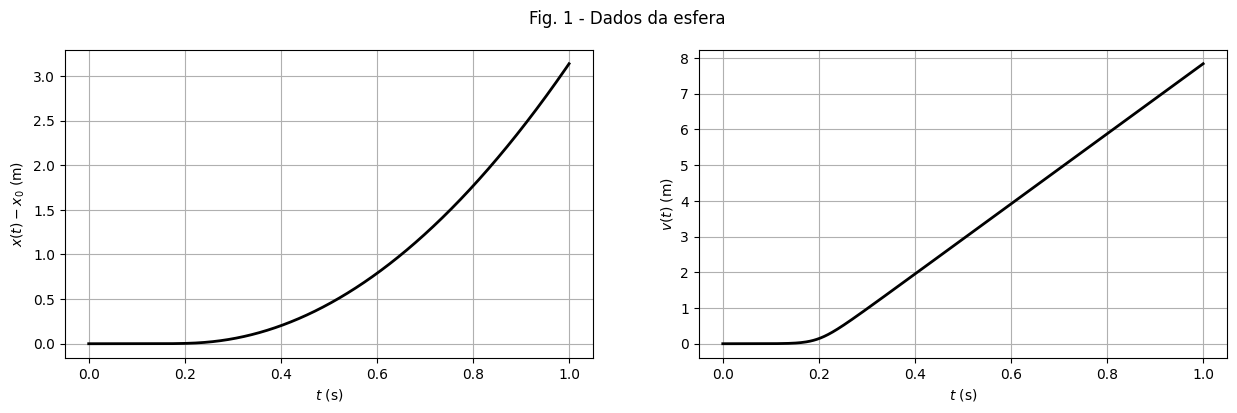

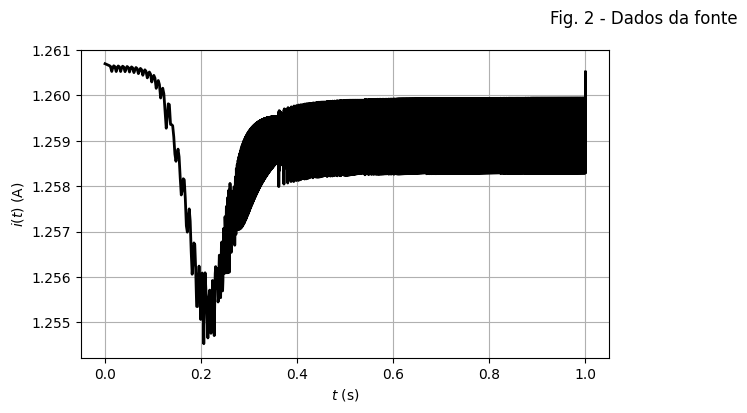

In [31]:
import matplotlib.pyplot as plt

# --- Position plot --- 
fig = plt.figure(figsize=(15,4))
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[1,:]-x0, 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$x(t)-x_0$ (m)');
fig.suptitle('Fig. 1 - Dados da esfera');

plt.subplot(1, 2, 2)
plt.plot(sol.t, sol.y[2,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$v(t)$ (m)');

# --- Source plot ---
fig = plt.figure(figsize=(15,4))
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[0,:], 'k', linewidth=2); 
plt.grid(True);
plt.xlabel('$t$ (s)');
plt.ylabel('$i(t)$ (A)');
fig.suptitle('Fig. 2 - Dados da fonte');

# Atividades do Trabalho Computacional
## Sintonizando o PID
### REE
Para representarmos um sistema com realimentação PID, precisamos alterar a REE que foi apresentada anteriormente.
A entrada realimentada por um PID é dada pela seguinte equação:
\begin{equation}
u(t) = u_0 + K_p e(t) + K_i \int_0^t e(t) + K_d \dot e(t)
\end{equation}

Como usaremos essa entrada no sistema, precisamos acrescentar um estado na representação de forma que fique no formato adequado. Sendo assim, criaremos o estado $\dot E$:

\begin{equation}
\dot E(t) = e(t)
\end{equation}
O que significa que $E(t) = \int_0^t e(t)$.

Dessa forma, podemos substituí-lo na primeira equação do sistema e teremos o seguinte REE:

\begin{eqnarray}
\dot i &=& - \frac{R}{L(x)}i - \frac{Bl(i,x)}{L(x)} v + \frac{u_0 + K_p e(t) + K_i \dot E + K_d \dot e(t)}{L(x)}\\
\dot x &=& v \\
\dot v &=& g - \frac{f_m(i,x)}{m} \\
\dot E &=& x - x_0
\end{eqnarray}

## Adicionando incerteza à malha de realimentação